In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
btc = pd.read_csv("coin_Bitcoin.csv")
eth = pd.read_csv("coin_Ethereum.csv")
xrp = pd.read_csv("coin_XRP.csv")
doge = pd.read_csv("coin_Dogecoin.csv")

btc.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [13]:
btc['Date'] = pd.to_datetime(btc['Date'])
eth['Date'] = pd.to_datetime(eth['Date'])
xrp['Date'] = pd.to_datetime(xrp['Date'])
doge['Date'] = pd.to_datetime(doge['Date'])

btc = btc.sort_values('Date')
eth = eth.sort_values('Date')
xrp = xrp.sort_values('Date')
doge = doge.sort_values('Date')

btc = btc.dropna()
eth = eth.dropna()
xrp = xrp.dropna()
doge = doge.dropna()

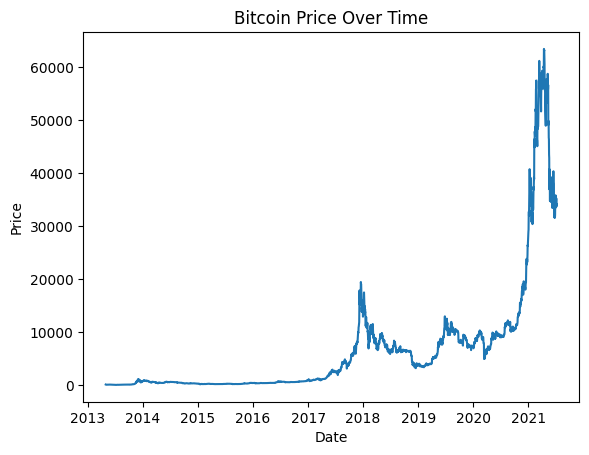

In [5]:
plt.plot(btc['Date'], btc['Close'])
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Graph shows the overall growth trend of bitcoin with noticeable spikes and dips which shows high volatility.

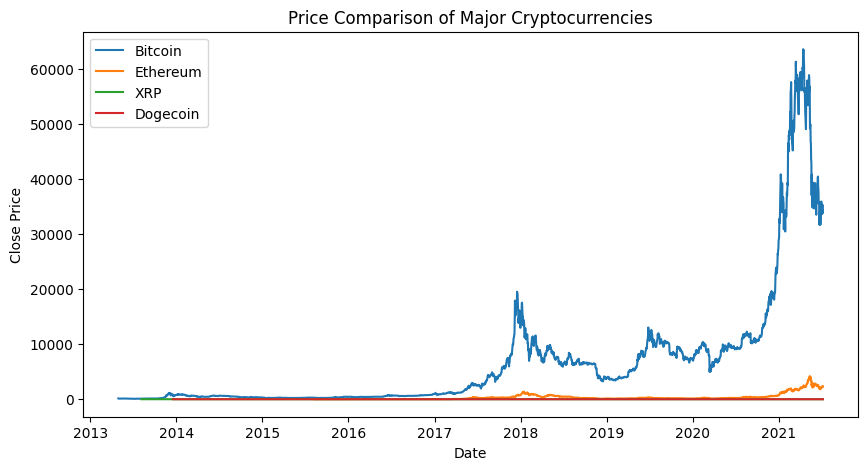

In [14]:
plt.figure(figsize=(10,5))
plt.plot(btc['Date'], btc['Close'], label='Bitcoin')
plt.plot(eth['Date'], eth['Close'], label='Ethereum')
plt.plot(xrp['Date'], xrp['Close'], label='XRP')
plt.plot(doge['Date'], doge['Close'], label='Dogecoin')

plt.legend()
plt.title("Price Comparison of Major Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

Graph compares the closing prices between Bitcoin, Ethereum, XRP, and Dogecoin over time. The difference in scale is due to the overall dominance Bitcoin has relative to prices in comparison to the others.

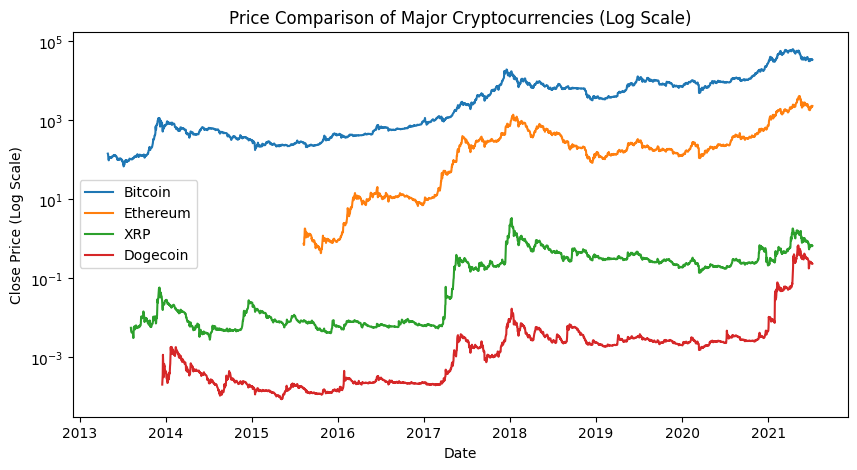

In [16]:
plt.figure(figsize=(10,5))
plt.plot(btc['Date'], btc['Close'], label='Bitcoin')
plt.plot(eth['Date'], eth['Close'], label='Ethereum')
plt.plot(xrp['Date'], xrp['Close'], label='XRP')
plt.plot(doge['Date'], doge['Close'], label='Dogecoin')

plt.yscale('log') 
plt.legend()
plt.title("Price Comparison of Major Cryptocurrencies (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Close Price (Log Scale)")
plt.show()

Graph for price comparison but put into Log Scale to better observe the growth and change relative to each other visually without the overpowering scale of Bitcoin. 

In [17]:
btc['Returns'] = btc['Close'].pct_change()
eth['Returns'] = eth['Close'].pct_change()
xrp['Returns'] = xrp['Close'].pct_change()
doge['Returns'] = doge['Close'].pct_change()

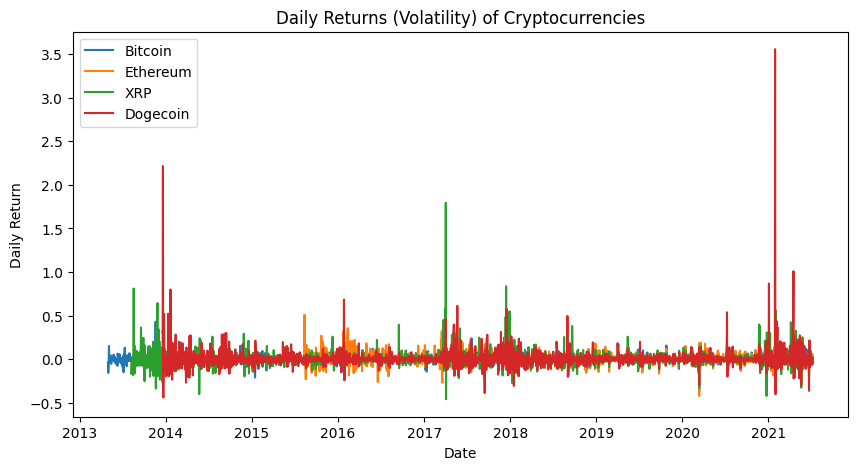

In [18]:
plt.figure(figsize=(10,5))

plt.plot(btc['Date'], btc['Returns'], label='Bitcoin')
plt.plot(eth['Date'], eth['Returns'], label='Ethereum')
plt.plot(xrp['Date'], xrp['Returns'], label='XRP')
plt.plot(doge['Date'], doge['Returns'], label='Dogecoin')

plt.legend()
plt.title("Daily Returns (Volatility) of Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

Graph shows the return/volatility of each cryptocurrency. This represents the daily price changes with higher volatility being directly due to larger fluctuations in the day to day prices.

In [19]:
combined = pd.DataFrame({
    'Bitcoin': btc.set_index('Date')['Close'],
    'Ethereum': eth.set_index('Date')['Close'],
    'XRP': xrp.set_index('Date')['Close'],
    'Dogecoin': doge.set_index('Date')['Close']
})

In [20]:
corr = combined.corr()
corr

,Bitcoin,Ethereum,XRP,Dogecoin
Bitcoin,1.000000,0.904147,0.620505,0.648206
Ethereum,0.904147,1.000000,0.699698,0.837741
XRP,0.620505,0.699698,1.000000,0.488873
Dogecoin,0.648206,0.837741,0.488873,1.000000


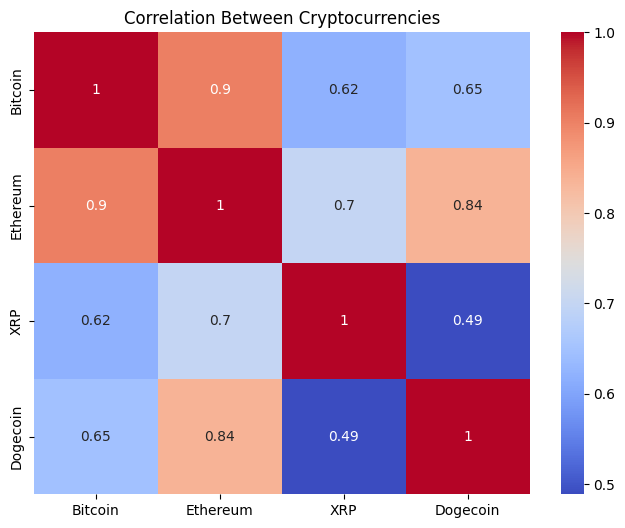

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Cryptocurrencies")
plt.show()

Heatmap shows the correlation between these cyrptocurrencies based on the closing prices. With the values closer to 1.0 indicate a stronger positive relationship, which means that their movement in the market moves together. Values further from 1.0 indicate that their relationship is not. From the heatmap, Bitcoin and Ethereum show to have a strong relationship especially when compared to the other relationships on the map. 

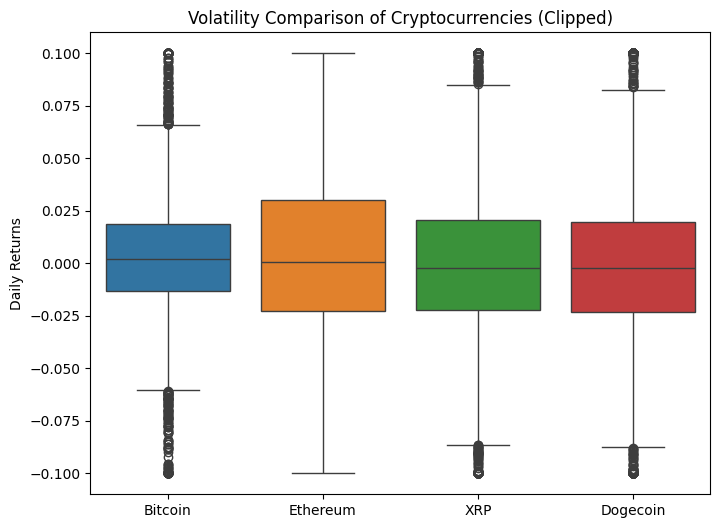

In [24]:
returns_df = pd.DataFrame({
    'Bitcoin': btc['Returns'],
    'Ethereum': eth['Returns'],
    'XRP': xrp['Returns'],
    'Dogecoin': doge['Returns']
})

plt.figure(figsize=(8,6))
sns.boxplot(data=returns_df.clip(-0.1, 0.1))

plt.title("Volatility Comparison of Cryptocurrencies (Clipped)")
plt.ylabel("Daily Returns")
plt.show()

Boxplot compares the distribution of the daily returns for each of the cryptocurrencies (extereme outliers removed for the sake of readability) Bitcoin shows the most narrow box which indicates more consistency in daily pricing while Ethereum has the widest box and suggest that it has the most day to day variation in price.

These analysis examined the pricing changes, volatility, and trading volume and the relationships between one another. Bitcoin showed long term growth and relatively stable day to day movement. Ethereum showed more variation in day to day prices but much less outliers and extreme value changes. XRP and Dogecoin had relatively similar trends in their patterns in volatility and the presence of extreme spikes/outliers. 